In [10]:
%load_ext autoreload
%autoreload 2

import numpy as np
from numpy import pi
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import LinearSegmentedColormap
colors = ['C0','C1','C2','C3','C4','C5','C6','C7','C8','C0','C1','C2','C3','C4','C5','C6','C7','C8']

from blochK.plotting import plot_FS, plot_bandstruc
from blochK.plotting.utils import sample_square

from blochK.observable import exp_value_O,conductivity_orbital_resolved, local_dos_QPI, find_Gamma
import blochK

from alter_surf.hamiltonian_DLKK import create_H_DLKK_3D
import alter_surf.utils3D
from alter_surf.hamiltonian_CuMnAs import H_3D_fct, H_slab_fct

from numpy import cos, sin 

from tqdm import tqdm
import pickle

#create a custom colormap bkr
# grab the endpoints from bwr
cmap_bwr = matplotlib.colormaps["bwr"]
# define your own colormap: blue → black → red
colors = [cmap_bwr(0.0), (0, 0, 0, 1),cmap_bwr(1.0)]
cmap_bkr = LinearSegmentedColormap.from_list("bkr", colors, N=256)



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In the entire script $k_z$ is the out of plane direction and $k_x,k_y$ are in plane. This makes more sense but is rotated with respect to the nature paper. This is implementing the stuff Fernando has on the overleaf

$(k_x,k_y,k_z) \rightarrow (k_x,k_z,-k_y)$

In [4]:

Hparam0 = dict(t=1, tz=1, Delta1=0, Delta2=1, mu=0)

#true 3D Hamiltonian
H3D = blochK.Hamiltonian3D(H_3D_fct, param= Hparam0, basis = ['spin','z-layer','sublattice'])
H3D.add_operator('spin',np.array([1,1,1,1,-1,-1,-1,-1]))


#effective 3D Hamiltonian with kz as parameter
H3D_as2D = blochK.Hamiltonian2D(lambda kx,ky,kz=0,**kwargs: H_3D_fct(kx,ky,kz,**kwargs), param=Hparam0, basis = ['spin','z-layer','sublattice'])
H3D_as2D.add_operator('spin',np.array([1,1,1,1,-1,-1,-1,-1]))


#slab Hamiltonian
Hparam0 = dict(len_z=21, t=1, tz=1, Delta1=0, Delta2=0, mu=0, PBC=False)
Hparam0['numb_z'] = (Hparam0['len_z']+1)//2
if Hparam0['len_z']%2==0: #len_z even: everything fine
    H = blochK.Hamiltonian2D(H_slab_fct, param=Hparam0)
    H.add_suboperator('proj',np.eye(H.n_orbitals))
    H.add_suboperator('spin',np.array([1,1,1,1,-1,-1,-1,-1]))
    H.add_suboperator('layer',np.array([1,1,-1,-1,1,1,-1,-1]))
    H.add_operator('spin',np.kron(np.ones(Hparam0['numb_z']),np.array([1,1,1,1,-1,-1,-1,-1])))
else: #len_z odd: need to project out last layer from operator definitions
    H = blochK.Hamiltonian2D(H_slab_fct, param=Hparam0)
    #construct projector to project out the last layer, which to use with operators
    selected = np.delete(np.arange(H.param['numb_z']*8),[-6,-5,-2,-1])
    proj = np.eye(H.param['numb_z']*8)[*np.ix_(selected),...]
    H.add_suboperator('proj',proj)
    #add the other operators. operators need be constructed with H.suboperator.proj.dot(O)
    H.add_suboperator('spin', np.array([1,1,1,1,-1,-1,-1,-1]))
    H.add_suboperator('layer',np.array([1,1,-1,-1,1,1,-1,-1]))
    print(proj.shape, H.n_orbitals)
    H.add_operator('spin',proj.dot(np.kron(np.ones(Hparam0['numb_z']),np.array([1,1,1,1,-1,-1,-1,-1]))))


# # Hparam_hierachy = dict(t=10, tz=20,t1=30,t3=0,Delta1=50, Delta2=60, Delta3=70, mu=0)
# ks=H.BZ.sample(21)
# Hk = H.evaluate(*ks)#,override_params=Hparam_hierachy)
# Hk = np.abs(Hk).max(axis=(-2,-1))

# vmax = Hk.max()
# im = plt.imshow(Hk.real,vmin=0.1,vmax=vmax,cmap='tab10')
# plt.colorbar(im)



def project_doublelayer(layer):
    """Constructs the observable to project in layer and layer+1"""
    if layer%2==0: #for even layers
        return np.kron(alter_surf.utils3D.projector2layer(layer//2,len_z=H.param['numb_z']),np.abs(H.suboperator.layer))
    else: #odd layers
        layer1 = np.kron(alter_surf.utils3D.projector2layer(layer//2,len_z=H.param['numb_z']),H.suboperator.layer<0)
        layer2 = np.kron(alter_surf.utils3D.projector2layer(layer//2+1,len_z=H.param['numb_z']),H.suboperator.layer>0)
        return layer1 + layer2



(84, 88) 84


## Looking at different k_z momenta

I pushed the Fermi energy a little bit down to see the Fermi surface of the 2 bands which merge to create the nodal line.


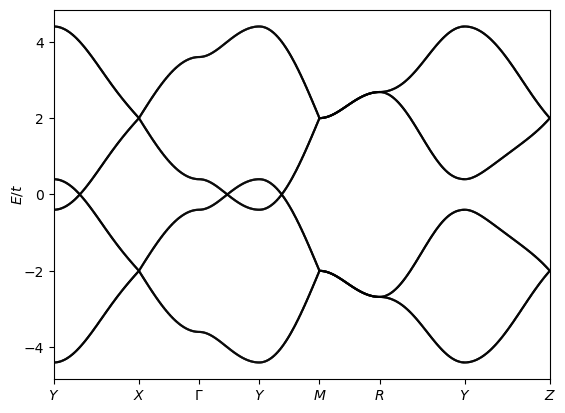

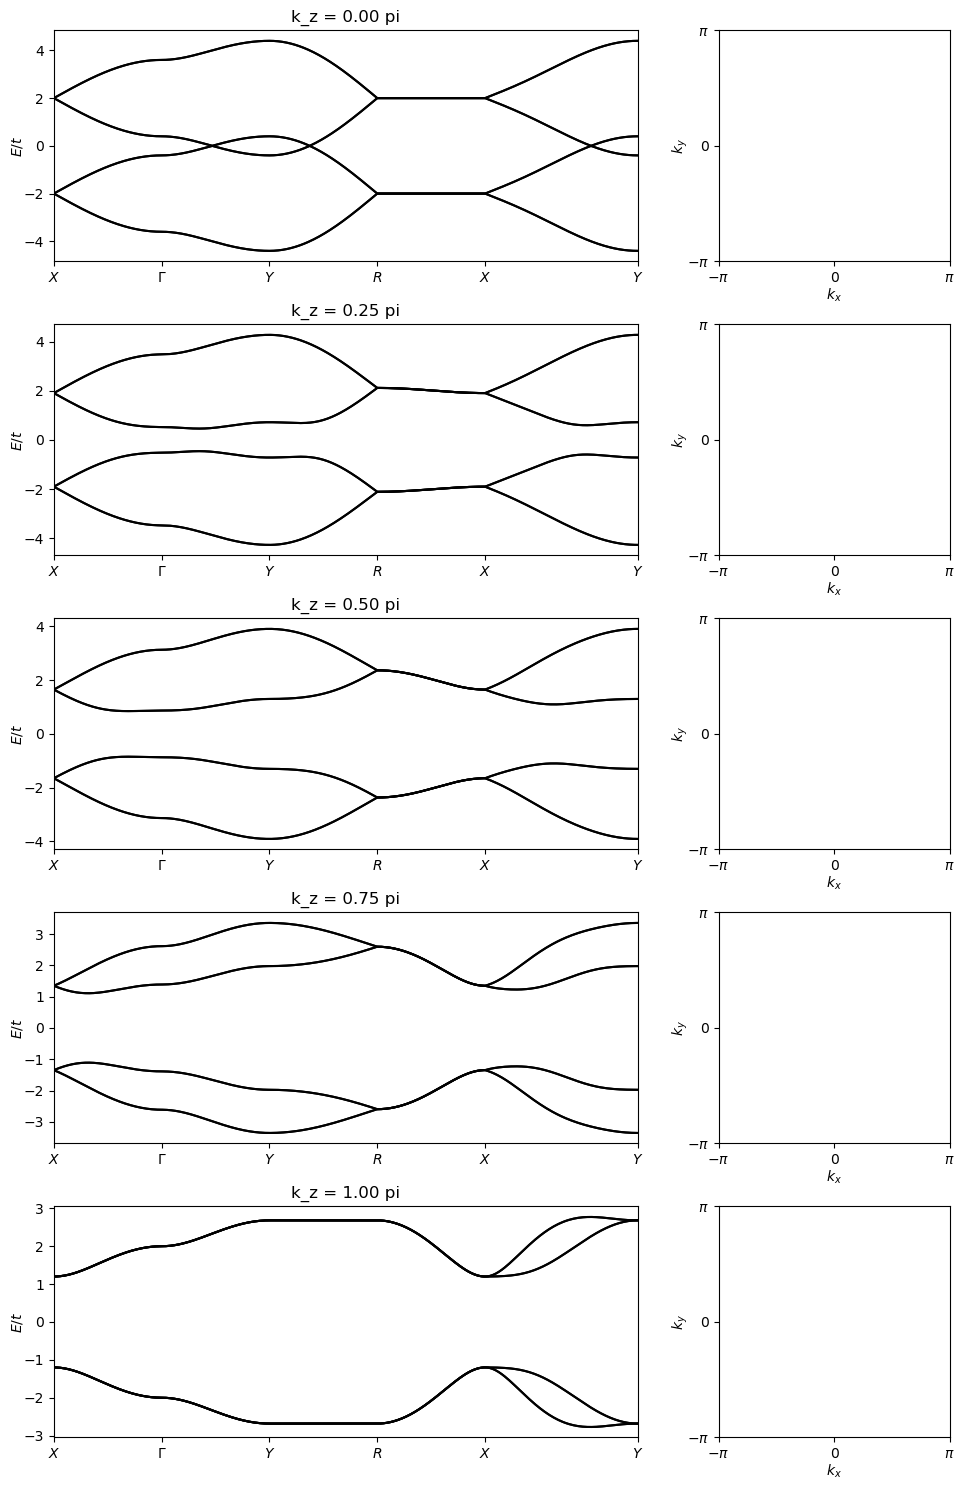

In [5]:
#Hparam0 = dict(t=0.4, tz=1, Delta0=1.2,Delta1=0.5,Delta3=0.5,mu=0.05,V_layer_z=0.)
Hparam0 = dict(t=0.4, tz=1, Delta0=0.6, Delta1=0.6,Delta3=0.6, mu=0., lambda2=0.) #nodal line #mu=0.05
#Hparam0 = dict(t=0.4, tz=1, Delta0=0.6, Delta1=0.6,Delta3=0.6 ,mu=0., dtpp=0.2) #nice values for Weyl cones
#Hparam0 = dict(t=0.4, tz=1, Delta0=1.2,Delta1=0.5,Delta3=0.5,mu=0.,V_layer_z=1,t2=-0.3, dt2=0.) #Weyl cones, but mirror broken, at different energy


Hparams = dict(**Hparam0,kz=np.linspace(0,np.pi,5)) #np.linspace(0,np.pi,4)

#Delta2 creates the Blob at Y
#tz split it to get Nodal line
#t nodal line elongated along Y

#checked and gives the same results as H_3D_fct
#Delta1

Hparam_list = blochK.utils.parameters.dict2listofdict(Hparams)




#plotting full 3D bandstructure
labels = ['Y','X','\\Gamma','Y','M','R','Y','Z']
fig, ax = plt.subplots(1,1)
H3D.set_params(Hparam0)
plot_bandstruc(ax,H3D,labels_points_path=labels,cmap='bwr',coloring_operator=H3D.operator.spin)


#plotting kz slices
labels = ['X',r'\Gamma',"Y","R","X",'Y']
coloring_operator = H3D_as2D.operator.spin
cmap = 'bwr'
fig, axs = plt.subplots(len(Hparam_list),2,gridspec_kw={'width_ratios': [2,1]},figsize=(10,3*len(Hparam_list)))

for Hparam_iter,ax in zip(Hparam_list, axs):
    ax[0].set_title(f'k_z = {Hparam_iter["kz"]/np.pi:.2f} pi')
    H3D_as2D.set_params(Hparam_iter)
    plot_bandstruc(ax[0],H3D_as2D,labels_points_path=labels,cmap=cmap)
    plot_FS(ax[1],H3D_as2D,cmap=cmap,Lk=100,print_filling=False)

plt.tight_layout()

## Comparing different implementations

Make sure you choose an EVEN numbers of layers for that. Otherwise boundary conditions cannot be satisfied.

I everything is correct, the first and second figure should be identical.

{'t': 0.4, 'tz': 1, 'Delta0': 1.2, 'Delta1': 0.5, 'Delta3': 0.5, 'mu': 0.0, 'lambda2': 0.5, 'kz': np.float64(3.141592653589793)}
{'len_z': 10, 't': 0.4, 'tz': 1, 'Delta1': 0.5, 'Delta2': 0, 'mu': 0.0, 'PBC': False, 'numb_z': 5, 'Delta0': 1.2, 'Delta3': 0.5, 'lambda2': 0.5}


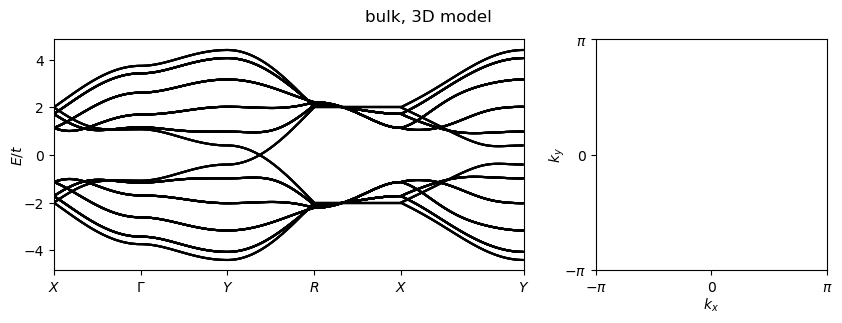

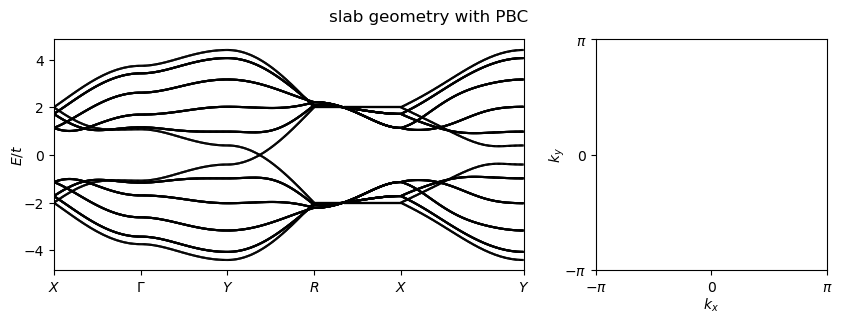

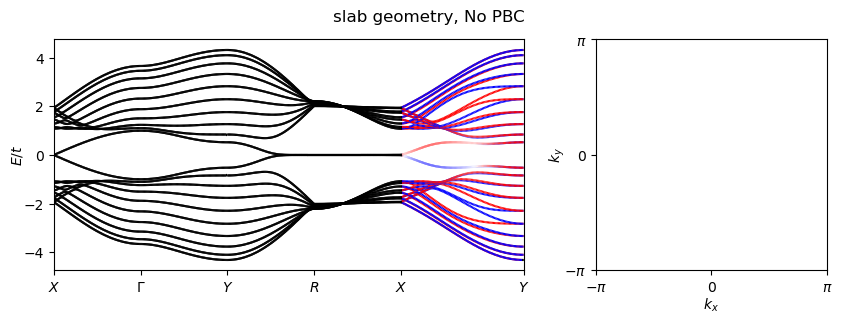

In [189]:
Hparam = Hparam0.copy()

H3D_as2D.update_params(Hparam)
H.update_params(Hparam)

print(H3D_as2D.param)
print(H.param)

labels = ['X',r'\Gamma',"Y","R","X",'Y']
coloring_operator = None
cmap = 'bwr'

#2D model
fig, [ax,ax1] = plt.subplots(1,2,gridspec_kw={'width_ratios': [2,1]},figsize=(10,3))
fig.suptitle('bulk, 3D model')
for kz in np.linspace(-2*np.pi,2*np.pi,H.param['len_z'],endpoint=False):
    H3D_as2D.update_params(dict(kz=kz))
    plot_bandstruc(ax,H3D_as2D,labels_points_path=labels,cmap=cmap,coloring_operator=H3D_as2D.operator.spin)
    plot_FS(ax1,H3D_as2D,cmap=cmap,coloring_operator=H3D_as2D.operator.spin,Lk=50,)
#ax.set_ylim(-0.4,0.4)

#with PBC
H.update_params(dict(PBC=True))
fig, [ax,ax1] = plt.subplots(1,2,gridspec_kw={'width_ratios': [2,1]},figsize=(10,3))
fig.suptitle('slab geometry with PBC')
plot_bandstruc(ax,H,labels_points_path=labels,cmap=cmap,coloring_operator=H.operator.spin)
plot_FS(ax1,H,cmap=cmap,coloring_operator=H.operator.spin,Lk=50,)
#ax.set_ylim(-0.4,0.4)

#without PBC
H.update_params(dict(PBC=False))
fig, [ax,ax1] = plt.subplots(1,2,gridspec_kw={'width_ratios': [2,1]},figsize=(10,3))
fig.suptitle('slab geometry, No PBC')
plot_bandstruc(ax,H,labels_points_path=labels,cmap=cmap,coloring_operator=H.operator.spin)
plot_FS(ax1,H,cmap=cmap,coloring_operator=H.operator.spin,Lk=50,)
#ax.set_ylim(-0.4,0.4)


## Computing surface properties

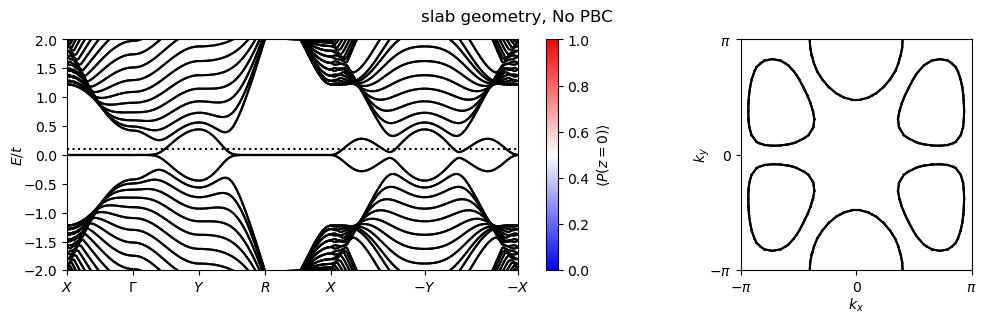

In [6]:
#without PBC
mu = 0.1
H.update_params(Hparam0)
H.update_params(dict(PBC=False))

labels = ['X',r'\Gamma',"Y","R","X",'-Y','-X']
coloring_operator = H.operator.spin #np.kron(projector2layer(-1,H.param['len_z']),H.suboperator.spin)
cmap = 'bwr' #'Greys'

fig, [ax,ax1] = plt.subplots(1,2,gridspec_kw={'width_ratios': [2,1]},figsize=(12,3))
fig.suptitle('slab geometry, No PBC')
plot_bandstruc(ax,H,labels_points_path=labels,cmap=cmap,coloring_operator=coloring_operator,threshold_degeneracy=2,N_samples=30)
ax.axhline(mu,color='k',ls=':' )
H.update_params(dict(mu=mu))
plot_FS(ax1,H,cmap=cmap,coloring_operator=coloring_operator,Lk=30,threshold_degeneracy=2)
H.update_params(dict(mu=0))
cbar = plt.colorbar(ax.collections[0], ax=ax, orientation='vertical')
cbar.set_label(r'$\langle P(z=0) \rangle $')

ax.set_ylim(-2,2)

fig = plt.gcf()

# from IPython.display import display
# ax.set_ylim(-0.4,0.4)
# display(fig)

In [ ]:
Lk = 50 #number of k-points in each direction

# Define the k-point grid
ks = sample_square(Lk)
#Diagonalize Hamiltonian
H.update_params(dict(PBC=False))
numb_z = H.param['numb_z']
es,psis = H.diagonalize(*ks)


def plot_spectral_density(ax,spectral_density,cmap='bwr',title_plot='',show_xlabel=True,show_ylabel=True,vmax='',vmin='',linthresh=1e-2,alphas=None):
    """Plots colored spin spectral density on ax,

    cmap: a matplotlib colormap
    title_plot: title of the plot if given
    vmax: maximum value for color scaling
    """
    if title_plot!='':
         ax.set_title(title_plot,fontsize=6)
    ax.set_aspect('equal')
    if show_xlabel:
        ax.set_xlabel(r'$k_x$',labelpad=1)
        ax.set_xticks([-pi,0,pi])
        ax.set_xticklabels([r'$-\pi$',0,r'$\pi$'])
    else:
        ax.set_xticklabels([])
    if show_ylabel:
        ax.set_ylabel(r'$k_y$',labelpad=-2.5)
        ax.set_yticks([-pi,0,pi])
        ax.set_yticklabels([r'$-\pi$',0,r'$\pi$'])
    else:
        ax.set_yticklabels([])
    ax.set_xlim(-pi,pi)
    ax.set_ylim(-pi,pi)
    #--------------
    if vmax == '':
        vmax = 1
    if vmin == '':
        vmin = -1
    
    if alphas is None:
        im = ax.imshow(spectral_density.T,extent=(-pi,pi,-pi,pi),origin='lower',cmap=cmap,norm=matplotlib.colors.SymLogNorm(linthresh=linthresh,vmin=vmin,vmax=vmax))
    else:
        im = ax.imshow(spectral_density.T,extent=(-pi,pi,-pi,pi),origin='lower',cmap=cmap,norm=matplotlib.colors.SymLogNorm(linthresh=linthresh,vmin=vmin,vmax=vmax),alpha=alphas.T)
    return im




Gamma = 0.1


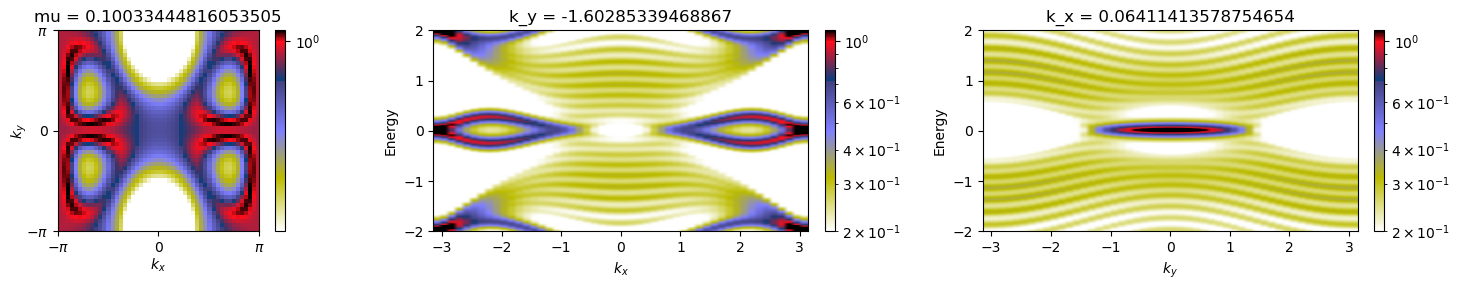

In [8]:
mu = 0.1 #energy at which the momentum resolved spectral density is computed
energies = np.linspace(-2,2,300)

layer=0
Gamma = 0.1#0.04#find_Gamma(es)
print(f'Gamma = {Gamma}')

#compute spectral density
Os = exp_value_O(H.suboperator.proj.dot(project_doublelayer(layer)),psis) #.shape=(n,kx,ky)

spectral_density0 = np.sum(Os[None]*Gamma/((es[None]-energies[:,None,None,None])**2+Gamma**2),axis=1)/numb_z #.shape=(len(energies),kx,ky)


fig,axs = plt.subplots(1,3,figsize=(16,3))

#kx,ky - Plot
idx_mu = np.argmin(np.abs(energies-mu))
axs[0].set_title(f'mu = {energies[idx_mu]}')
vmax = np.abs(spectral_density0[idx_mu]).max()
im = plot_spectral_density(axs[0],spectral_density0[idx_mu],show_ylabel=(layer==0),show_xlabel=True,vmax=vmax,vmin=2e-1,cmap='gist_stern_r')
plt.colorbar(im,ax=axs[0],fraction=0.046,pad=0.04)


#kx,energy - Plot
idx_ky = Lk//4
axs[1].set_title(f'k_y = {ks[1,0,idx_ky]}')
#vmax = np.abs(spectral_density0[:,:,idx_ky]).max()
im = axs[1].imshow(spectral_density0[:,:,idx_ky],norm=matplotlib.colors.LogNorm(vmin=2e-1,vmax=vmax),cmap='gist_stern_r',extent=(-pi,pi,energies[0],energies[-1]),origin='lower',aspect='auto')
axs[1].set_xlabel(r'$k_x$')
axs[1].set_ylabel('Energy')
plt.colorbar(im,ax=axs[1],fraction=0.046,pad=0.04)

#ky,energy - Plot
idx_kx = Lk//2
axs[2].set_title(f'k_x = {ks[0,idx_kx,0]}')
#vmax = np.abs(spectral_density0[:,idx_kx]).max()
im = axs[2].imshow(spectral_density0[:,idx_kx],norm=matplotlib.colors.LogNorm(vmin=2e-1,vmax=vmax),cmap='gist_stern_r',extent=(-pi,pi,energies[0],energies[-1]),origin='lower',aspect='auto')
axs[2].set_xlabel(r'$k_y$')
axs[2].set_ylabel('Energy')
plt.colorbar(im,ax=axs[2],fraction=0.046,pad=0.04)

plt.tight_layout()



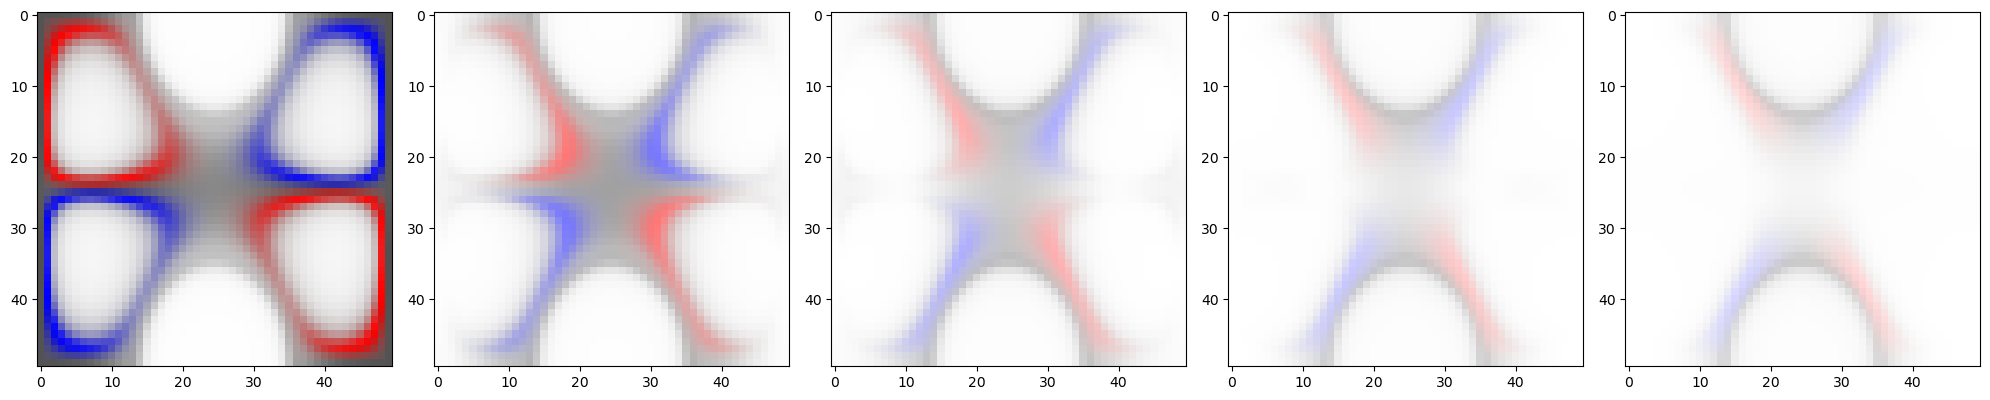

In [ ]:
mu = 0.05
layers = np.linspace(0,H.param['len_z']-1,5,dtype=int)
layers = [0,1,2,3,4]
Gamma = 0.04#0.04#find_Gamma(es)


fig,axs = plt.subplots(1,len(layers),figsize=(4*len(layers),4))

for ax,layer in zip(axs,layers):

    #this we need to improve if we want to measure the last layer
    coloring_operator = H.suboperator.proj.dot(project_doublelayer(layer))*H.operator.spin #projected spin_operator

    #compute spin spectral density
    Os = exp_value_O(coloring_operator,psis) #.shape=(n,y,x)
    spectral_density_spin = np.sum(Os*Gamma/((es-mu)**2+Gamma**2),axis=0)/numb_z

    #compute spectral density
    Os = exp_value_O(H.suboperator.proj.dot(project_doublelayer(layer)),psis) #.shape=(n,y,x)
    spectral_density0 = np.sum(Os*Gamma/((es-mu)**2+Gamma**2),axis=0)/numb_z

    if layer == 0:
        vmax_spin = np.abs(spectral_density_spin).max()
        vmax0 = np.abs(spectral_density0).max()


    alphas = spectral_density0/vmax0

    #ax.imshow(spectral_density[i],cmap='gray_r')

    imT = plot_spectral_density(ax_column[0],spectral_density_spin,title_plot='Layer '+str(layer),show_ylabel=(layer==0),show_xlabel=False,vmax=vmax_spin,vmin=-vmax_spin)
    ax.imshow(spectral_density_spin.T,cmap=cmap_bkr,alpha=alphas.T)


# #Plot spin spectral density and spectral density separately
# fig,axs = plt.subplots(2,len(layers),figsize=(4*len(layers),8))

# for ax_column,layer in zip(axs.T,layers):
#     #this we need to improve if we want to measure the last layer
#     coloring_operator = H.suboperator.proj.dot(project_doublelayer(layer))*H.operator.spin #projected spin_operator

#     #compute spin spectral density
#     Os = exp_value_O(coloring_operator,psis) #.shape=(n,y,x)
#     spectral_density_spin = np.sum(Os*Gamma/((es-mu)**2+Gamma**2),axis=0)/numb_z

#     #compute spectral density
#     Os = exp_value_O(H.suboperator.proj.dot(project_doublelayer(layer)),psis) #.shape=(n,y,x)
#     spectral_density0 = np.sum(Os*Gamma/((es-mu)**2+Gamma**2),axis=0)/numb_z

#     if layer == 0:
#         vmax_spin = np.abs(spectral_density_spin).max()
#         vmax0 = np.abs(spectral_density0).max()

#     imT = plot_spectral_density(ax_column[0],spectral_density_spin,title_plot='Layer '+str(layer),show_ylabel=(layer==0),show_xlabel=False,vmax=vmax_spin,vmin=-vmax_spin)
#     imB = plot_spectral_density(ax_column[1],spectral_density0,show_ylabel=(layer==0),show_xlabel=True,vmax=vmax0,vmin=1e-2,cmap='gist_stern_r')
    
#     #colorbars for each plot
#     plt.colorbar(imT,ax=ax_column[0],fraction=0.046,pad=0.04)
#     plt.colorbar(imB,ax=ax_column[1],fraction=0.046,pad=0.04)    


# # plt.colorbar(imT,ax=axs[0,-1],fraction=0.046,pad=0.04)
# # plt.colorbar(imB,ax=axs[1,-1],fraction=0.046,pad=0.04)

plt.tight_layout()


In [10]:
## creating the spectral density data

layers = np.arange(0,H.param['len_z']-1,1,dtype=int)

spectral_densitys = []
spin_spectral_densitys = []
for layer in tqdm(layers):
    proj_spin = H.suboperator.proj.dot(project_doublelayer(layer))*H.operator.spin #projected spin_operator #projected spin_operator

    #compute spin spectral density
    Os = exp_value_O(proj_spin,psis) #.shape=(n,y,x)
    spin_spectral_density = np.sum(Os*Gamma/((es-mu)**2+Gamma**2),axis=0)/H.param['len_z']
    spin_spectral_densitys.append(spin_spectral_density)
    #compute spectral density
    Os = exp_value_O(np.abs(proj_spin),psis) #.shape=(n,y,x)
    spectral_density0 = np.sum(Os*Gamma/((es-mu)**2+Gamma**2),axis=0)/H.param['len_z']
    spectral_densitys.append(spectral_density0)

spectral_densitys = np.array(spectral_densitys)
spin_spectral_densitys = np.array(spin_spectral_densitys)

with open('analysis/spectral_densitys_Weyl.pkl','wb') as f:
    pickle.dump({'spectral_density':spectral_densitys,
                 'spin_spectral_density':spin_spectral_densitys,
                 'layers':layers,
                 'k_mesh':ks}, f)
f.close()



  0%|          | 0/30 [00:00<?, ?it/s]


NameError: name 'psis' is not defined

## Spin transport

In [233]:
#setting parameters
Lk = 40 #number of k-points in each direction

# Calculate spin conductivity
cond_tensor = conductivity_orbital_resolved(H,energy=mu,Lk=Lk,optimize='path') #.shape=(localH,x,y)

In [234]:
#2) way of dealing with this tensor: construct full observable and then contract (slower but does't matter)
#we can compute pairs (0,1), (1,2), (2,3), ...
spin_cond = []; cond0 = []

layers = np.arange(0,H.param['len_z']-1,1) #specify 

for layer in layers:
    Dens_op_layer = H.suboperator.proj.dot(project_doublelayer(layer))
    Spin_op_layer = H.suboperator.proj.dot(project_doublelayer(layer))*H.operator.spin #projected spin_operator
    #spin_cond_xx.append(np.sum(Spin_op_layer*cond_tensor[:,0,0]))
    spin_cond.append(np.sum(Spin_op_layer[:,None,None]*cond_tensor,axis=0))
    #cond0_xx.append(np.sum(Dens_op_layer*cond_tensor[:,0,0]))
    cond0.append(np.sum(Dens_op_layer[:,None,None]*cond_tensor,axis=0))

spin_cond = np.array(spin_cond)
cond0 = np.array(cond0)
#the index order matters here!
#spin_cond[:,1,0] is sigma_yx, that is current in y direction when E_x applied


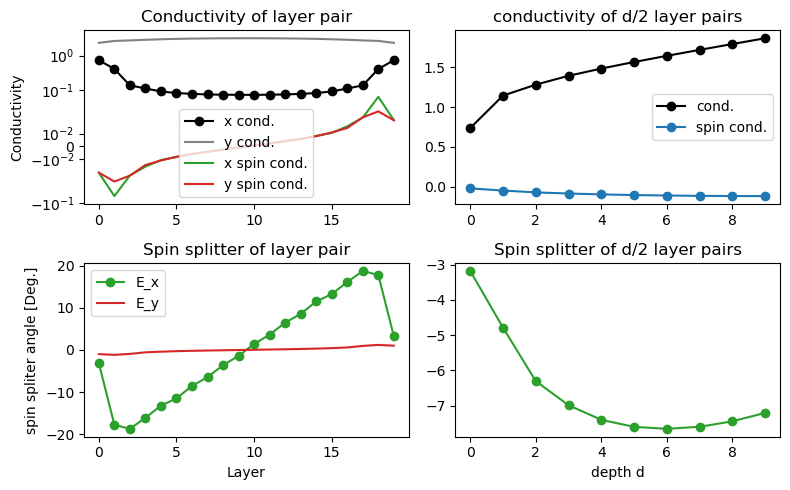

In [235]:
fig,axs = plt.subplots(2,2,figsize=(8,5))

#layer resolved
axs[0,0].set_title('Conductivity of layer pair')
axs[0,0].plot(layers,cond0[:,0,0],'ko-',label='x cond.')
axs[0,0].plot(layers,cond0[:,1,1],'-',color='gray',label='y cond.')
axs[0,0].plot(layers,spin_cond[:,1,0],'-',color='C2',label='x spin cond.')
axs[0,0].plot(layers,spin_cond[:,0,1],'-',color='C3',label='y spin cond.')
axs[0,0].set_ylabel('Conductivity')
axs[0,0].legend()
axs[0,0].set_yscale('symlog',linthresh=3e-2)

axs[1,0].set_title('Spin splitter of layer pair')
axs[1,0].plot(layers,2*np.arctan(spin_cond[:,1,0]/cond0[:,0,0])*180/pi,'o-',color='C2',label='E_x')
axs[1,0].plot(layers,2*np.arctan(spin_cond[:,0,1]/cond0[:,1,1])*180/pi,'-',color='C3',label='E_y')
axs[1,0].legend()
axs[1,0].set_xlabel('Layer')
axs[1,0].set_ylabel('spin spliter angle [Deg.]')

#layer summed
lz2 = H.param['len_z']//2
xs = np.arange(0,lz2)
axs[0,1].set_title('conductivity of d/2 layer pairs')
axs[0,1].plot(xs,np.cumsum(cond0[:lz2,0,0]),'ko-',label='cond.')
axs[0,1].plot(xs,np.cumsum(spin_cond[:lz2,0,1]),'o-',label='spin cond.')
axs[0,1].legend()

axs[1,1].set_title('Spin splitter of d/2 layer pairs')
axs[1,1].plot(xs,2*np.arctan(np.cumsum(spin_cond[:lz2,0,1])/np.cumsum(cond0[:lz2,0,0]))*180/pi,'o-',color='C2')
axs[1,1].set_xlabel('depth d')


plt.tight_layout()


5it [02:04, 24.88s/it]


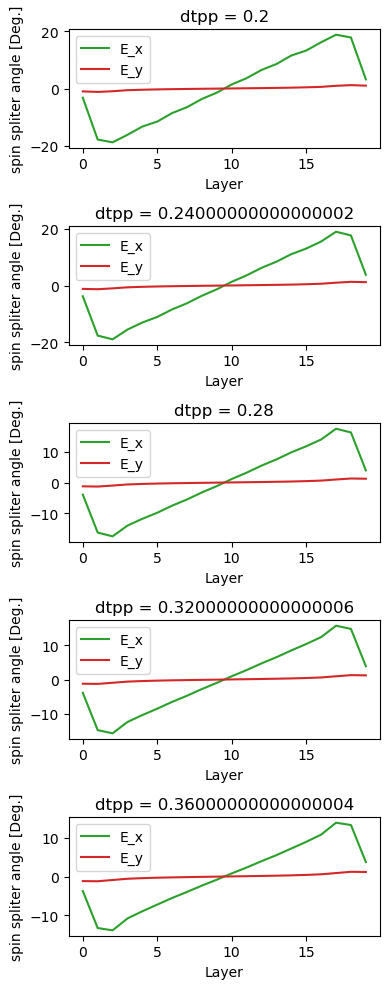

In [236]:
#setting parameters
Lk = 40 #number of k-points in each direction

vals = np.arange(0.2,0.4,0.04)

fig,axs = plt.subplots(len(vals),1,figsize=(4,2*len(vals)))

for idx, dtpp in tqdm(enumerate(vals)):
    H.update_params(dict(dtpp=dtpp))

    cond_tensor = conductivity_orbital_resolved(H,energy=mu,Lk=Lk,optimize='path') #.shape=(localH,x,y)


    spin_cond = []; cond0 = []
    layers = np.arange(0,H.param['len_z']-1,1) #specify 
    for layer in layers:
        Dens_op_layer = H.suboperator.proj.dot(project_doublelayer(layer))
        Spin_op_layer = H.suboperator.proj.dot(project_doublelayer(layer))*H.operator.spin #projected spin_operator
        #spin_cond_xx.append(np.sum(Spin_op_layer*cond_tensor[:,0,0]))
        spin_cond.append(np.sum(Spin_op_layer[:,None,None]*cond_tensor,axis=0))
        #cond0_xx.append(np.sum(Dens_op_layer*cond_tensor[:,0,0]))
        cond0.append(np.sum(Dens_op_layer[:,None,None]*cond_tensor,axis=0))

    spin_cond = np.array(spin_cond)
    cond0 = np.array(cond0)


    axs[idx].set_title('dtpp = '+str(dtpp))
    axs[idx].plot(layers,2*np.arctan(spin_cond[:,1,0]/cond0[:,0,0])*180/pi,'-',color='C2',label='E_x')
    axs[idx].plot(layers,2*np.arctan(spin_cond[:,0,1]/cond0[:,1,1])*180/pi,'-',color='C3',label='E_y')
    axs[idx].legend()
    axs[idx].set_xlabel('Layer')
    axs[idx].set_ylabel('spin spliter angle [Deg.]')

plt.tight_layout()


